# Who spoke what and when — walkthrough (runs locally or on Google Colab)

This notebook takes one noisy, overlapping Hindi/Hinglish conversation through all three stages and shows what each stage produces.

**On Colab:** Runtime → Change runtime type → T4 GPU. Add your Hugging Face token under *Secrets* (🔑) as `HF_TOKEN` (the account must have accepted the model terms listed in the README). Then run all cells.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    REPO = "https://github.com/darshanrajagoli/whospoke.git"
    if not os.path.exists("whospoke"):
        subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    os.chdir("whospoke")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-colab.txt"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "asteroid==0.7.0"], check=True)

In [2]:
import sys, os, json, time
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

torch 2.5.1+cu121 | CUDA: True | NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 1 · A test conversation

If the simulated data set has not been built on this machine, we build one small conversation on the fly from IndicVoices (needs the Hugging Face token).

In [3]:
from whospoke.audio import load, SR
from IPython.display import Audio, display
from whospoke.paths import SYNTH, conversation
idx_path = SYNTH / "test/index.csv"
if idx_path.exists():
    idx = pd.read_csv(idx_path)
    row = idx[(idx.n_speakers == 3) & (idx.overlap_level == "ovl-high") & (idx.noise == "market5")].iloc[0]
    conv_dir = conversation(row.path)
else:
    subprocess.run([sys.executable, str(ROOT / "scripts/build_dataset.py"), "--test-groups", "2", "--dev-groups", "1"], check=True)
    idx = pd.read_csv(idx_path); row = idx[idx.overlap_level == "ovl-high"].iloc[-1]; conv_dir = conversation(row.path)
ref = json.loads((conv_dir / "reference.json").read_text(encoding="utf-8"))
mix = load(conv_dir / "mixture.wav")
print(ref["id"], f"| {ref['duration_s']:.0f} s | speakers: {ref['speakers']} | overlap: {ref['overlap_ratio']:.0%}")
display(Audio(mix, rate=SR))

test_g01_3spk_ovl-high_market5 | 66 s | speakers: ['S1', 'S2', 'S3'] | overlap: 14%


## 2 · The full pipeline (Order B)

In [4]:
from whospoke.pipeline import Pipeline
from whospoke.__main__ import tuned_diarizer
pipe = Pipeline("B", diarizer=tuned_diarizer("B", "spectral"))
result = pipe.run(mix)
print(result.transcript(hinglish=True))
print("\ntimings (s):", result.timings)

C:\Users\darsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\whospoke-data\venv\Lib\site-packages\asteroid\models\base_models.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  conf = torch.load(cached_model, map_location="cpu")

Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Fetching 404 files:  59%|█████▉    | 240/404 [00:00<00:00, 2398.17it/s]

Fetching 404 files: 100%|██████████| 404/404 [00:00<00:00, 2318.93it/s]

C:\whospoke-data\venv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


C:\whospoke-data\venv\Lib\site-packages\pyannote\audio\utils\reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(


C:\whospoke-data\venv\Lib\site-packages\pyannote\audio\models\blocks\pooling.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  std = sequences.std(dim=-1, correction=1)


[00:01 - 00:07] Speaker_A: haan ji namaste hello namaskar main restaurant aisi baat kar raha hoon ji ji ye to hamari speshliti hai sir
[00:08 - 00:15] Speaker_A: haan aapko bata de agar aap shadi le jaoge to teen sau rupae milegi aapko aur agar aap use trai karva ke ya sabji banva ke le jaoge
[00:16 - 00:18] Speaker_A: to aapko sadhe chaar sau rupye ki pad jaegi
[00:20 - 00:26] Speaker_A: to haan verayti to dher hai aap aake dekh sakte ho jaise aapko kisi cheej ki jarurat matlab kisi alag tarike ki jarurat hai
[00:27 - 00:28] Speaker_A: kuch aake bhi aage
[00:28 - 00:31] Speaker_B: hote hain four isse rok hoti hai aur phejal hoti hai
[00:32 - 00:36] Speaker_B: ji sev hai aur yu sevi hai aapko kaun si karani hai
[00:37 - 00:38] Speaker_A: theek hai
[00:38 - 00:39] Speaker_A: ati
[00:39 - 00:47] Speaker_B: piece bata deti hoon meri yu cutting ke liye jo aapko samne matlab ke according batani hai ya phir samne se hi ghar par batana hai
[00:47 - 00:48] Speaker_A: ki kar denge tu
[00:48 - 0

## 3 · Stage 2 output: the speaker timeline vs the truth

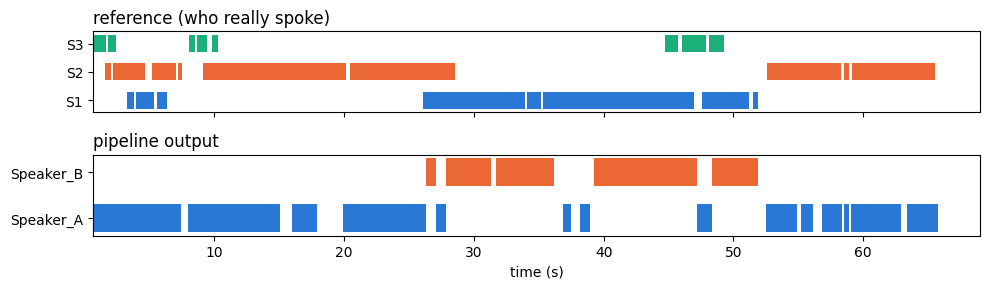

DER: 0.156


C:\whospoke-data\venv\Lib\site-packages\pyannote\metrics\utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3), sharex=True)
cols = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
def draw(ax, turns, title):
    names = sorted({t[2] for t in turns})
    for (s, e, spk) in turns:
        ax.barh(names.index(spk), e - s, left=s, color=cols[names.index(spk) % 5], height=0.6)
    ax.set_yticks(range(len(names)), names); ax.set_title(title, loc="left"); ax.grid(axis="y", visible=False)
draw(axes[0], [(s["start"], s["end"], s["speaker"]) for s in ref["segments"]], "reference (who really spoke)")
draw(axes[1], result.diarization.tuples(), "pipeline output")
axes[1].set_xlabel("time (s)"); plt.tight_layout(); plt.show()
from whospoke.metrics import der
truth = [tuple(a) for a in ref["activity"]]   # exact speech activity (start, end, speaker), as in the evaluation
print("DER:", round(der(truth, result.diarization.tuples())["der"], 3))

## 4 · Stage 1 output: listen to a separated overlap

In [6]:
ov = pipe._overlap_regions(result.diarization)   # where the overlap detector heard two voices
print(f"{len(ov)} overlap regions, {sum(e - s for s, e in ov):.1f} s in total; "
      f"{sum(l.audio == 'separated' for l in result.lines)} of {len(result.lines)} turns used separated audio")
if ov:
    s, e = max(ov, key=lambda x: x[1] - x[0])
    a, b = int(max(0, s - 0.5) * SR), int((e + 0.5) * SR)
    est = pipe.separator.separate(mix[a:b])
    print(f"overlap {s:.1f}–{e:.1f} s: mixture, then the two separated voices")
    display(Audio(mix[a:b], rate=SR)); display(Audio(est[0], rate=SR)); display(Audio(est[1], rate=SR))

8 overlap regions, 8.7 s in total; 8 of 19 turns used separated audio
overlap 26.1–28.3 s: mixture, then the two separated voices


## 5 · Stage 3 output: who-said-what score

In [7]:
from whospoke.metrics import cp_error
ref_text = {}
for s in sorted(ref["segments"], key=lambda s: s["start"]):
    ref_text.setdefault(s["speaker"], []).append(s["text"])
ref_text = {k: " ".join(v) for k, v in ref_text.items()}
print("cpWER (words wrong or given to the wrong speaker):", round(cp_error(ref_text, result.text_by_speaker())["rate"], 3))
result.save(ROOT / "results/runs/walkthrough"); print("saved to results/runs/walkthrough")

cpWER (words wrong or given to the wrong speaker): 0.427
saved to results/runs/walkthrough
